## Setup

In [ ]:
#%pip install -r requirements.txt

In [1]:
import json
import os
from dotenv import load_dotenv, find_dotenv
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
%config InlineBackend.figure_format = 'retina'
from VideoFTTools import VideoExtractor
from utils import *

# Load environment variables
if not load_dotenv(find_dotenv(), override=True):
    raise IOError("Error: .env file could not be loaded!")

# Initialize OpenAI client with Entra ID authentication
credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(
    credential, "https://cognitiveservices.azure.com/.default"
)
client = AzureOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    azure_ad_token_provider=token_provider,
    api_version="2025-04-01-preview"
)

# Central variables
project_name, version = "action-recognition-ft", "dev-01"  # For naming files and models
ft_deployment = f"{project_name}-{version}"  # Deployment name for the fine-tuned model
aoai_model_name = os.getenv("AZURE_OPENAI_DEPLOYMENT", "gpt-4.1")  # Base model deployment name (used for comparative evaluation)

# Dataset parameters
top_n_classes = 35  # Limit dataset to the top N most frequent classes (101 for full dataset)
train_samples = 3000  # Number of training samples (None for complete size)
val_samples = 600  # Number of validation samples (None for complete size)
test_samples = 600  # Number of testing samples (None for complete size)

# Video processing parameters
no_frames = 5  # Number of frames to extract per video
interval_seconds = 1  # Interval in seconds between extracted frames

# Reproducibility
random_seed = 0  # Seed for reproducibility of random operations

# Azure Storage configuration, optional for uploading the frames to Azure Storage. Alternatively, frames will be base64-encoded and included in the JSONL dataset files directly.
container_name = "frames"  # Azure container name for storing video frames as JPEGs
connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

# Deployment configuration for fine-tuned model, optional for code based deployment. Alternatively, use the Azure AI Foundry portal.
subscription_id = os.getenv("SUBSCRIPTION_ID")  # Azure subscription ID
resource_name = os.getenv("AOAI_RESOURCE")  # Azure OpenAI resource name

rg_name = os.getenv("RESOURCE_GROUP")  # Azure resource group name

# ANSI escape codes for bold formatting in console outputs
bold_start, bold_end = '\033[1m', '\033[0m'

## Few-Shot Inference with Video Frame Examples
The following cell demonstrates **few-shot prompting** for **British Sign Language (BSL) recognition**: we provide the model with 6 example video sequences from `tests/samples/`, each showing a person signing a different concept in BSL (label derived from the filename). Then we use `tests/good_morning_test.mp4` or `tests/good_night_test.mp4` as the query video to test whether the model can identify the signed concept based on the examples.

In [ ]:
# Global variable to hold few-shot system messages
system_messages = system_message_for_few_shot_examples(os.path.join("tests", "samples-nb"),
                                                       aoai_model_name, no_frames=no_frames)

def analyze_test_video(video_path: str, expected_concept: str):
    print(f"\nQuery video: {video_path} (ground truth: {expected_concept})")

    """Extract frames from the test video, build the message, and get prediction from the model."""
    extractor = VideoExtractor(video_path)
    #test_frames = extractor.extract_video_frames(interval_seconds)
    test_frames = extractor.extract_n_video_frames(n=no_frames)
    test_frames_b64 = [f["frame_base64"] for f in test_frames]

    # Add the test video as the final user turn
    messages = system_messages.copy()  # Start with the few-shot messages
    
    # Test without few-shots
    '''
    few_shot_system_message = f"""You are an expert in British Sign Language (BSL) recognition from video.
    You are provided with a series of extracted frames from videos showing a person performing signs in BSL. Each frame includes a timestamp in the lower-left corner, formatted as 'video_time: mm:ss:msec'.
    The possible BSL concepts are:
    {all_labels_str}
    Respond with a valid JSON object in this exact format:
    {{
        "concept": "The identified BSL concept from the provided list, spelled exactly as given."
    }}
    """
    messages = [{"role": "developer", "content": few_shot_system_message}]
    '''
    
    messages.append({
        "role": "user",
        "content": [
            {"type": "text", "text": f"Now identify the BSL concept being signed in this new video:"},
            *[{"type": "image_url", "image_url": {"url": f"data:image/jpg;base64,{b64}"}} for b64 in test_frames_b64],
        ]
    })

    #print(f"MESSAGES: {json.dumps(messages, indent=2)}")

    # Get prediction from the model
    print(f"\n{bold_start}Calling model: {aoai_model_name}{bold_end}")
    response = client.chat.completions.create(
        model=aoai_model_name,
        messages=messages,
        temperature=0.5,
        seed=random_seed,
        response_format={"type": "json_object"}
    )
    result = json.loads(response.choices[0].message.content)

    print(f"\n{bold_start}Results:{bold_end}")
    print(f"  Predicted concept: {result['concept']}")
    print(f"  Ground truth:      {expected_concept}")
    print(f"  Correct:           {'✅' if result['concept'] == expected_concept else '❌'}")

    # 6. Display the query frames for visual reference
    print(f"\n{bold_start}Query video frames:{bold_end}")
    query_extractor = VideoExtractor(video_path)
    query_frames = query_extractor.extract_n_video_frames(n=no_frames)
    #query_frames = query_extractor.extract_video_frames(interval_seconds)
    query_extractor.display_frames(query_frames, height=180)
    
    return result

Found 8 few-shot example videos:
  bye → tests\samples\bye.mp4
  good afternoon → tests\samples\good_afternoon.mp4
  good evening → tests\samples\good_evening.mp4
  good morning → tests\samples\good_morning.mp4
  good night → tests\samples\good_night.mp4
  hello → tests\samples\hello.mp4
  please → tests\samples\please.mp4
  see you soon → tests\samples\see_you_soon.mp4



Query video: tests\good_morning_test.mp4 (ground truth: good morning)

Calling model: gpt-4.1

Results:
  Predicted concept: good morning
  Ground truth:      good morning
  Correct:           ✅

Query video frames:



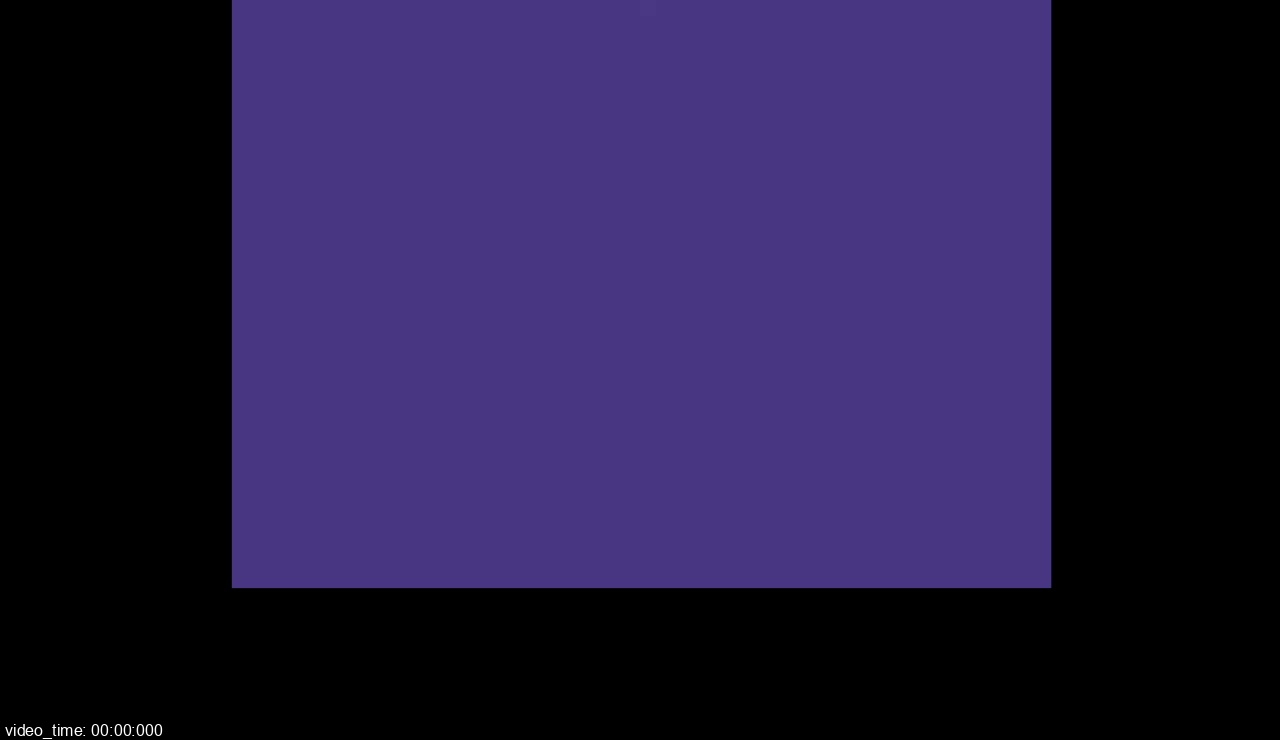
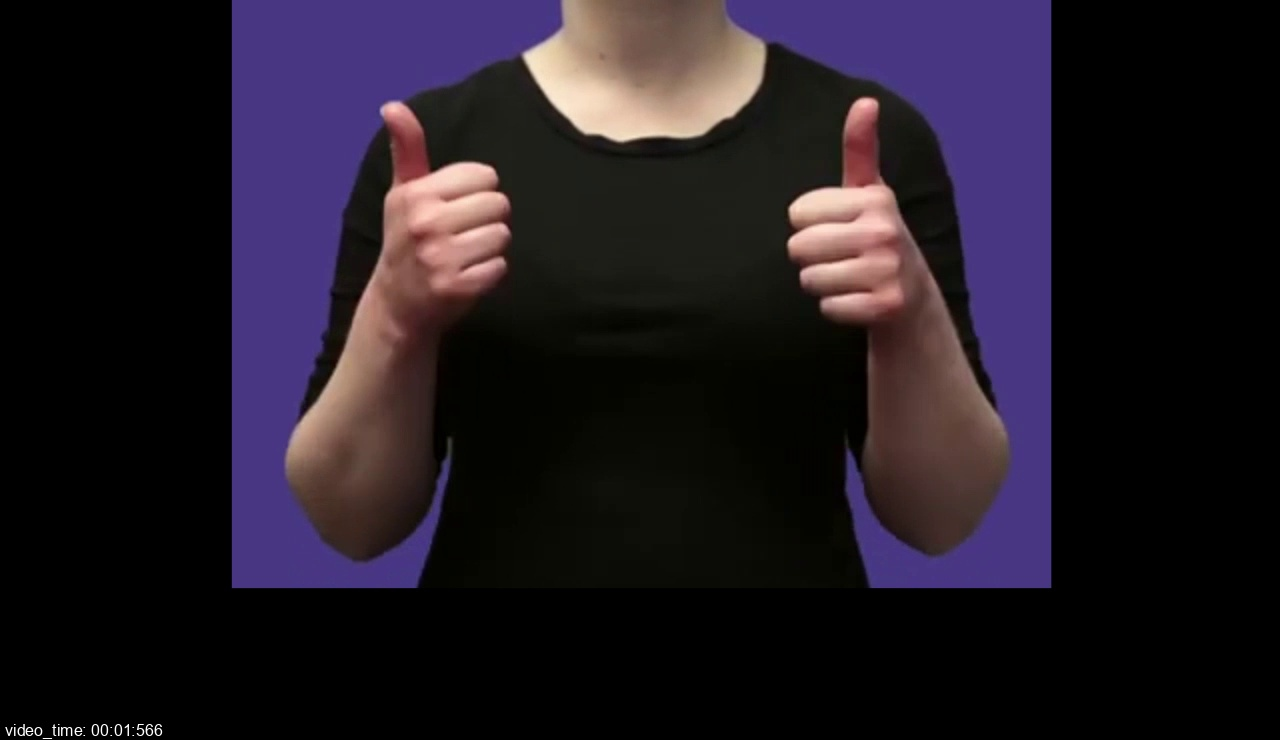
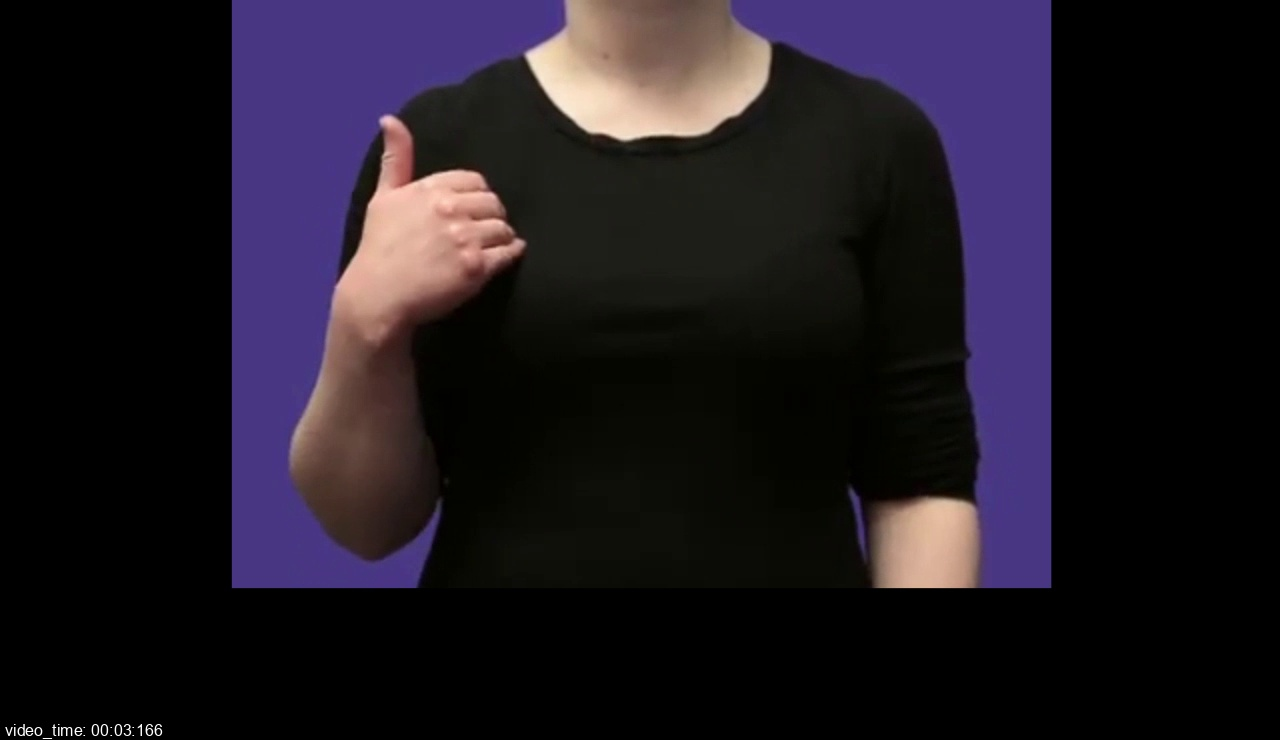
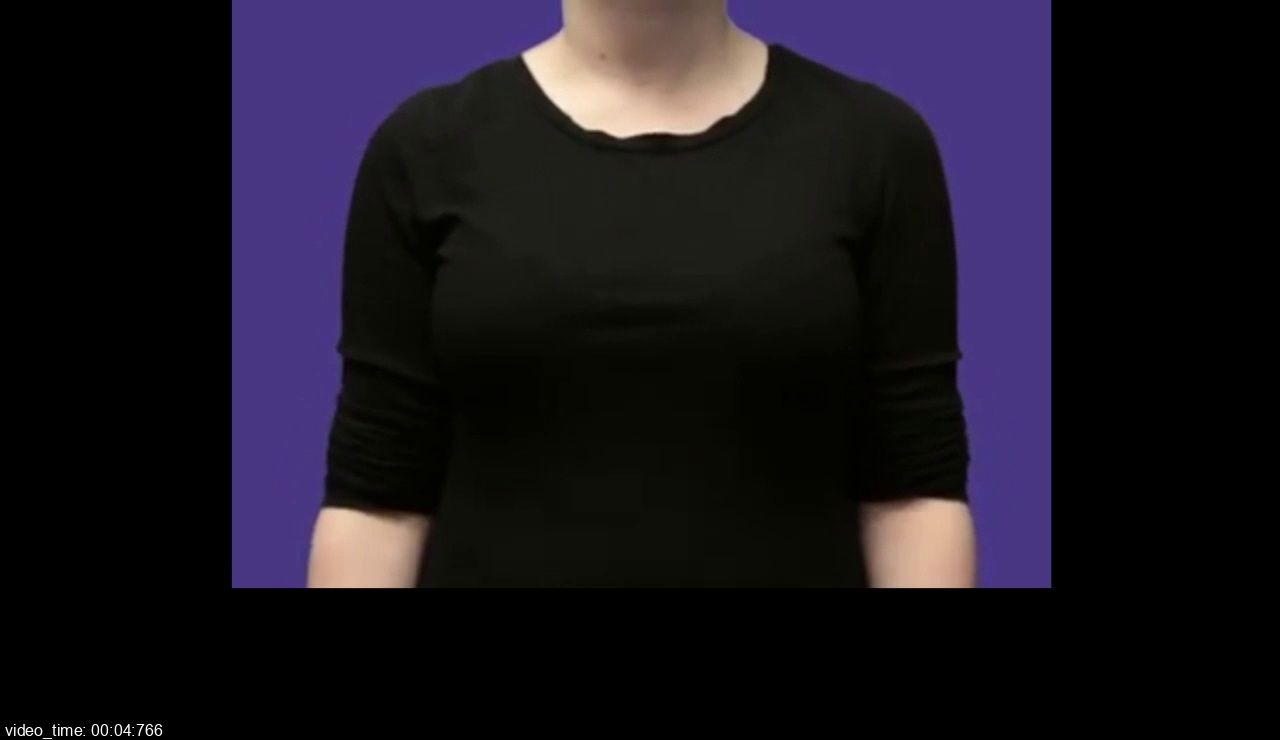
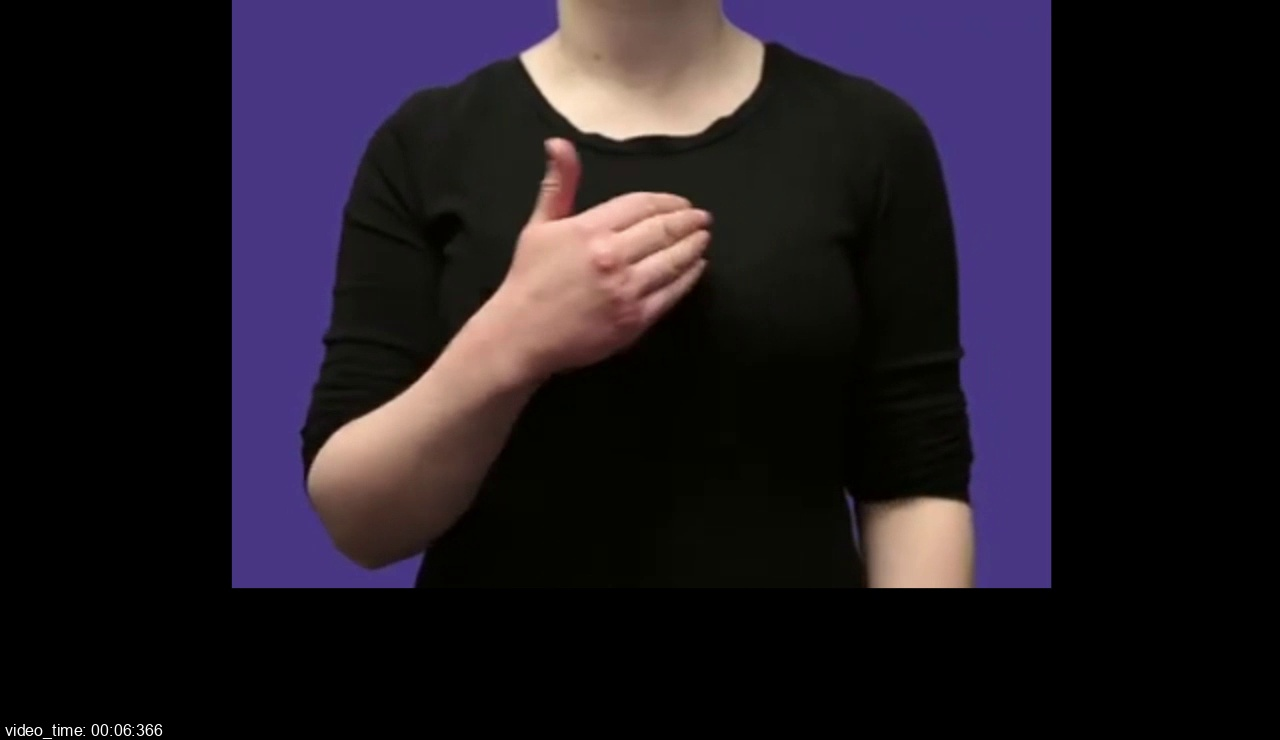

In [9]:
# Analyze the test video and get the predicted concept
result = analyze_test_video(video_path = os.path.join("tests", "good_morning_test.mp4"), 
                            expected_concept="good morning")


Query video: tests\good_night_test.mp4 (ground truth: good night)

Calling model: gpt-4.1

Results:
  Predicted concept: good night
  Ground truth:      good night
  Correct:           ✅

Query video frames:



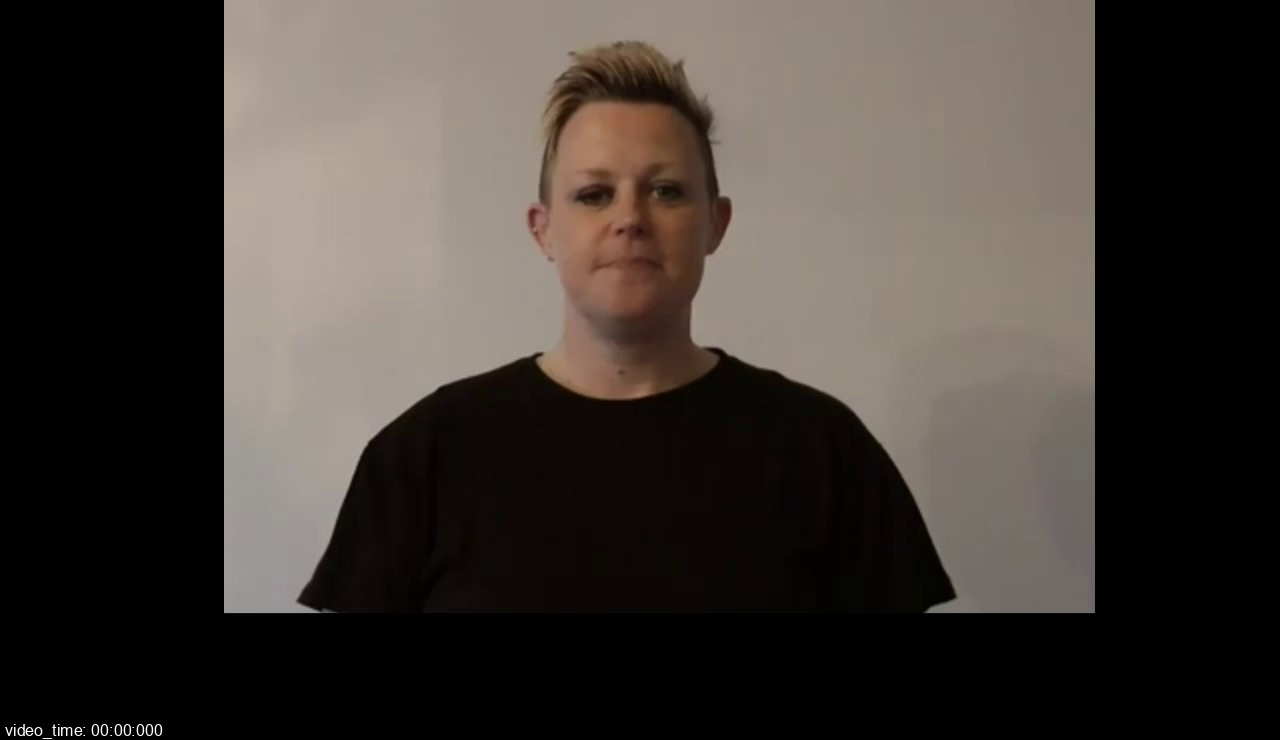
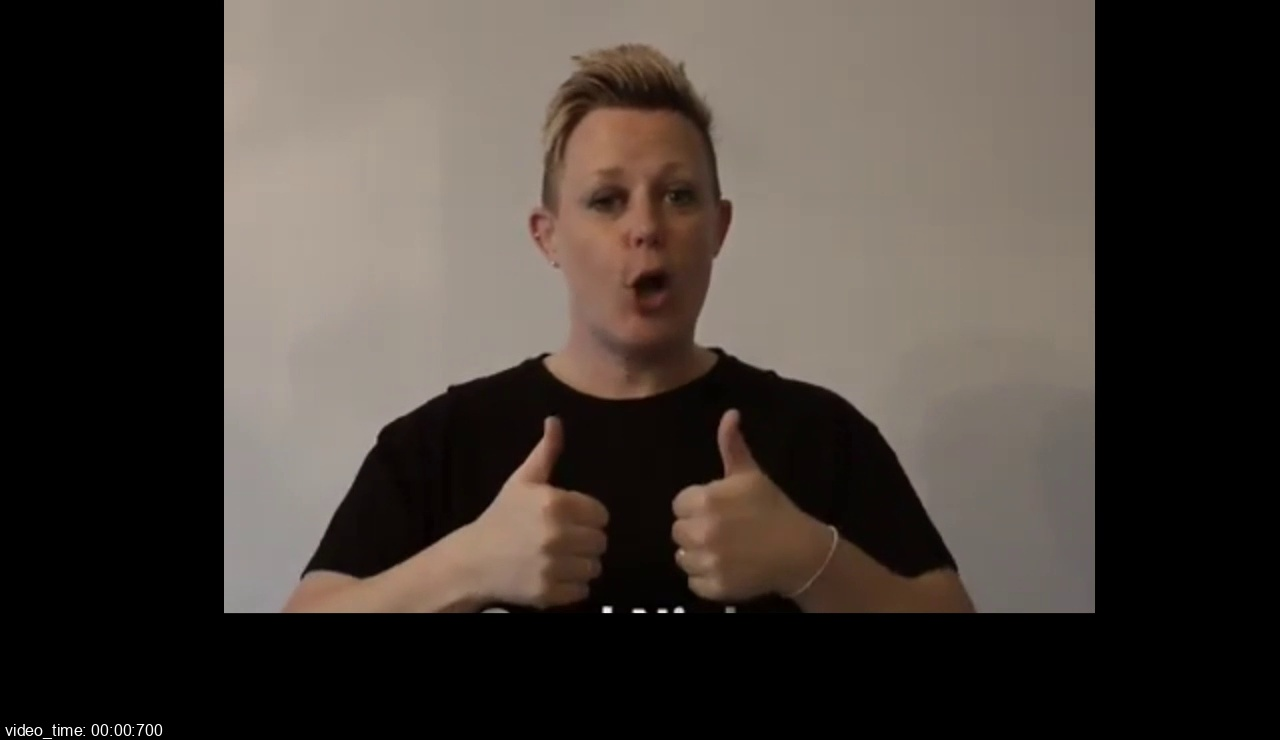
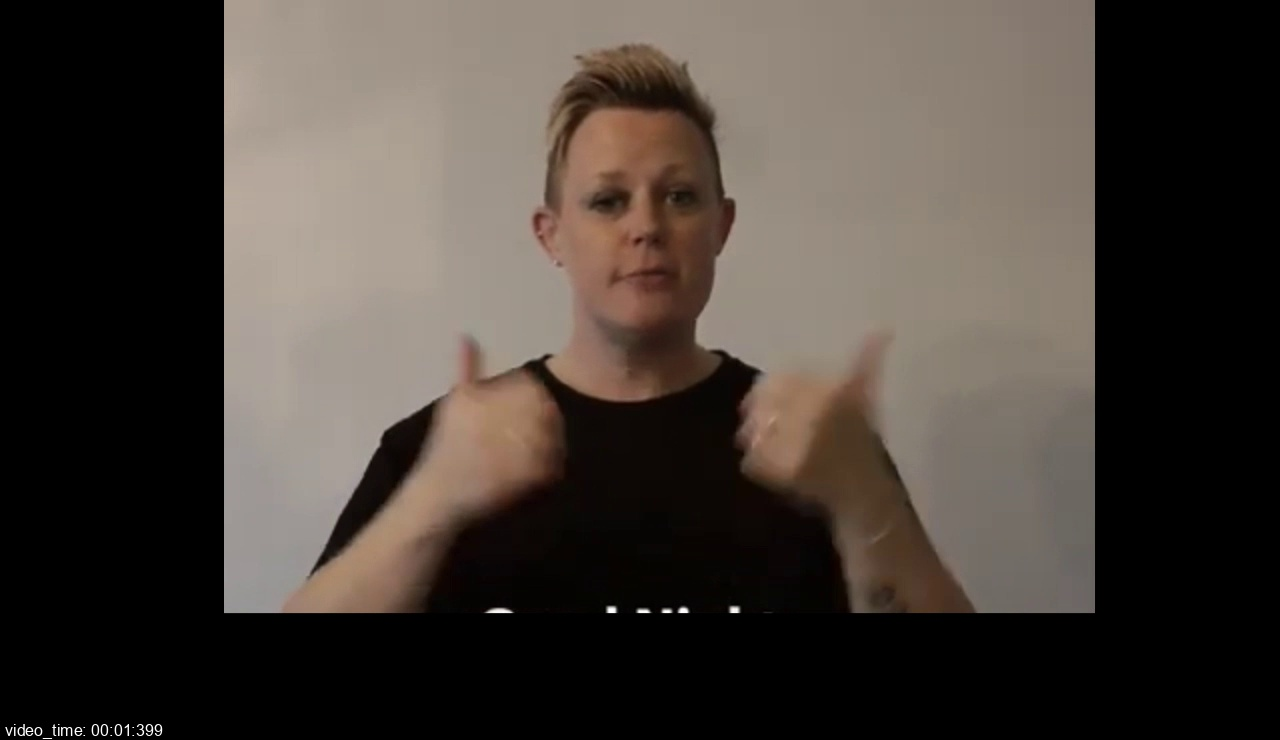
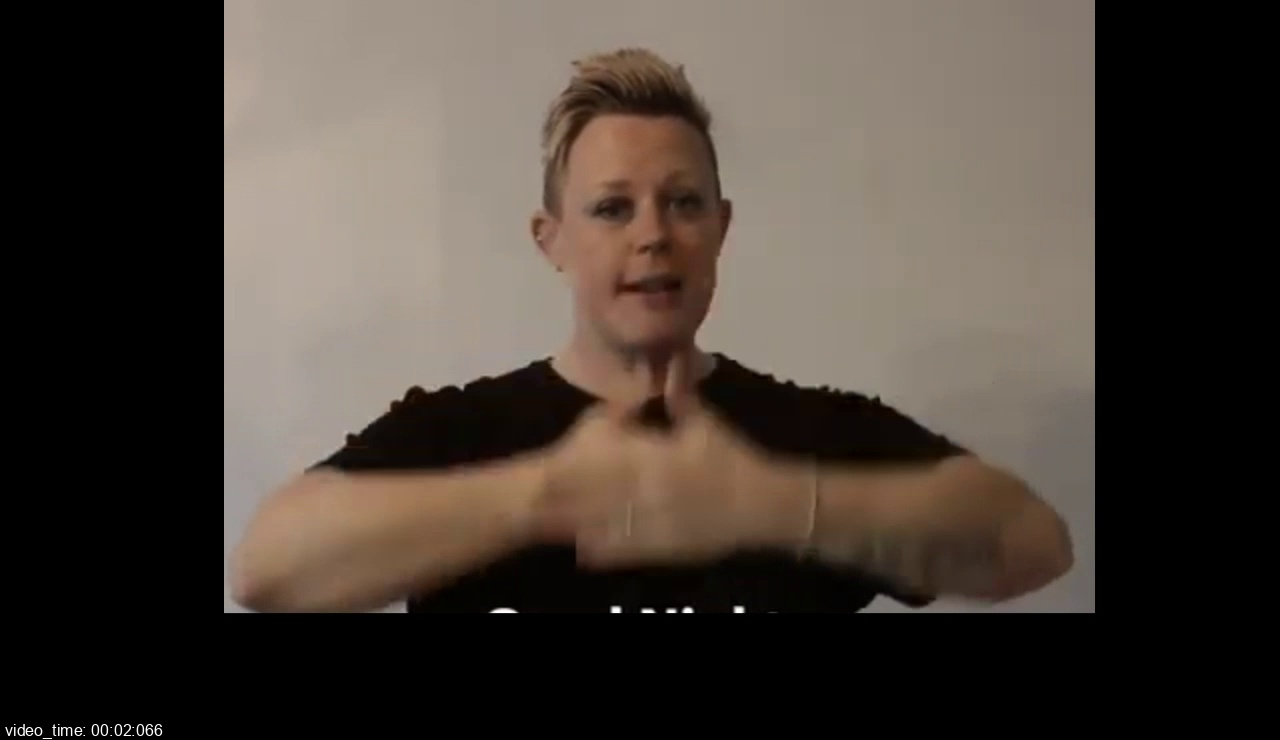
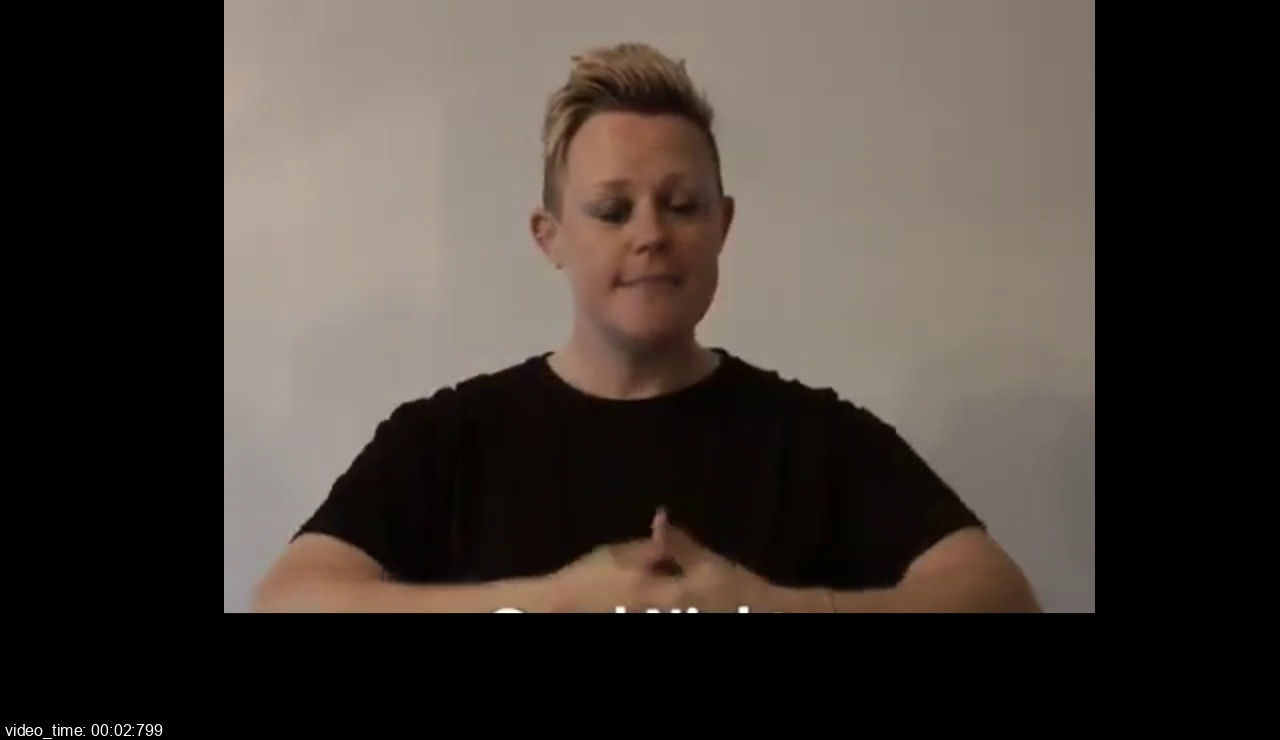

In [10]:
# Analyze the test video and get the predicted concept
result = analyze_test_video(video_path = os.path.join("tests", "good_night_test.mp4"), 
                            expected_concept="good night")

In [14]:
import os
import subprocess
import json
import pandas as pd
from IPython.display import display, HTML

def get_video_duration(filepath):
    """Get video duration in seconds using ffprobe."""
    try:
        result = subprocess.run(
            ["ffprobe", "-v", "quiet", "-print_format", "json", "-show_format", filepath],
            capture_output=True, text=True, timeout=10
        )
        info = json.loads(result.stdout)
        return round(float(info["format"]["duration"]), 2)
    except Exception as e:
        return f"Error: {e}"

# Define folders to analyze
base_path = r"c:\Angel\AI GBB\Azure OpenAI\AOAI-video-fine-tuning\tests"
folders = ["samples", "samples2", "more_samples"]

rows = []
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        continue
    for f in sorted(os.listdir(folder_path)):
        if f.lower().endswith(".mp4"):
            full_path = os.path.join(folder_path, f)
            duration = get_video_duration(full_path)
            rows.append({
                "Folder": folder,
                "Video": f,
                "Duration (s)": duration
            })

df = pd.DataFrame(rows)

# Summary stats
print(f"Total MP4 files found: {len(df)}")
print(f"Folders analyzed: {', '.join(folders)}\n")

# Per-folder summary
numeric = df[df["Duration (s)"].apply(lambda x: isinstance(x, (int, float)))]
summary = numeric.groupby("Folder")["Duration (s)"].agg(["count", "min", "max", "mean"]).round(2)
summary.columns = ["Count", "Min (s)", "Max (s)", "Mean (s)"]
print("=== Per-folder summary ===")
display(summary)

print("\n=== Full video list ===")
display(df)

Total MP4 files found: 33
Folders analyzed: samples, samples2, more_samples

=== Per-folder summary ===


,Count,Min (s),Max (s),Mean (s)
Folder,,,,
more_samples,25,10.73,37.50,16.65
samples,8,7.37,16.07,12.36



=== Full video list ===


,Folder,Video,Duration (s)
0,samples,bye.mp4,8.70
1,samples,good_afternoon.mp4,14.23
2,samples,good_evening.mp4,13.33
3,samples,good_morning.mp4,12.87
4,samples,good_night.mp4,15.17
5,samples,hello.mp4,7.37
6,samples,please.mp4,11.17
7,samples,see_you_soon.mp4,16.07
8,more_samples,again_please.mp4,16.30
9,more_samples,apology.mp4,16.87
